
#**Лабораторная работа №1: Первичное исследование данных**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
upl = files.upload()
# Загрузка данных
df = pd.read_csv('toyota.csv')  # Путь к вашему файлу
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.head(10)

Saving toyota.csv to toyota.csv
Размер датасета: 6738 строк, 9 столбцов


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,GT86,2016,16000,Manual,24089,Petrol,265,36.2,2.0
1,GT86,2017,15995,Manual,18615,Petrol,145,36.2,2.0
2,GT86,2015,13998,Manual,27469,Petrol,265,36.2,2.0
3,GT86,2017,18998,Manual,14736,Petrol,150,36.2,2.0
4,GT86,2017,17498,Manual,36284,Petrol,145,36.2,2.0
5,GT86,2017,15998,Manual,26919,Petrol,260,36.2,2.0
6,GT86,2017,18522,Manual,10456,Petrol,145,36.2,2.0
7,GT86,2017,18995,Manual,12340,Petrol,145,36.2,2.0
8,GT86,2020,27998,Manual,516,Petrol,150,33.2,2.0
9,GT86,2016,13990,Manual,37999,Petrol,265,36.2,2.0


# **1. Типы признаков и шкалы измерения**

**Задание 1.**

Для каждого признака датасета:
**1.** Укажите тип шкалы:
* номинальная
* порядковая
* интервальная
* шкала отношений / абсолютная


| Признак | Тип шкалы | Обоснование |
|---------|-----------|-------------|
| **model** | Номинальная | Названия моделей, нельзя упорядочить, математические операции бессмысленны |
| **year** | Интервальная / Абсолютная | Можно считать разницу лет, есть точка отсчета |
| **price** | Шкала отношений | Есть абсолютный ноль (0 GBP), можно считать отношения |
| **transmission** | Номинальная | Типы коробок передач (Manual, Automatic), нельзя упорядочить |
| **mileage** | Шкала отношений | Есть абсолютный ноль (0 миль), можно считать отношения |
| **fuelType** | Номинальная | Типы топлива (Petrol, Diesel), нельзя упорядочить |
| **tax** | Шкала отношений | Есть абсолютный ноль (0 GBP), можно считать отношения |
| **mpg** | Шкала отношений | Есть абсолютный ноль (0 миль/галлон), можно считать отношения |
| **engineSize** | Шкала отношений | Есть абсолютный ноль (0 литров), можно считать отношения |


**2.** Выберите два признака с разными шкалами и ответьте:
имеет ли смысл вычислять для них:
* среднее?
* медиану?
* моду?

какие агрегаты будут математически корректны, а какие - методологически неверны,
даже если pandas их считает?

### Признак 1: **model** (номинальная шкала)

| Агрегат | Имеет ли смысл? | Почему |
|---------|-----------------|--------|
| **Среднее (mean)** | НЕТ | Нельзя складывать и делить названия моделей |
| **Медиана (median)** | НЕТ | Нельзя упорядочить модели |
| **Мода (mode)** | ДА | Показывает самую популярную модель |

**Математически корректно:** только мода (самая часто встречающаяся модель)

**Методологически неверно:** среднее и медиана — pandas может выдать ошибку или бессмысленный результат

### Признак 2: **price** (шкала отношений)

| Агрегат | Имеет ли смысл? | Почему |
|---------|-----------------|--------|
| **Среднее (mean)** | ДА | Показывает среднюю цену, есть абсолютный ноль |
| **Медиана (median)** | ДА | Показывает цену "типичного" авто, устойчива к выбросам |
| **Мода (mode)** | ДА | Показывает самую частую цену (но может быть много уникальных) |

**Математически корректно:** среднее, медиана, мода — все имеют смысл

**Методологически верно:** все три агрегата можно использовать, но медиана предпочтительнее при наличии выбросов в данных


-----

#**2 Пропуски и их природа (MCAR / MAR / MNAR)**

**Задание 2. Диагностика типа пропусков**
Выберите признак с пропусками.

**1.** Сформулируйте три альтернативные гипотезы:
* что пропуски — MCAR;
* что пропуски — MAR;
* что пропуски — MNAR

**2.** Для каждой гипотезы:
* укажите, какие наблюдаемые признаки могут её подтвердить или опровергнуть;
* какие проверки вы бы выполнили (с реализацией).


## Введение
В датасете Toyota пропусков нет, поэтому для выполнения задания мы рассмотрим **гипотетическую ситуацию** — предположим, что в признаке **`engineSize`** (объём двигателя) есть пропуски. Этот признак выбран, так как он:
- связан с другими характеристиками (`model`, `fuelType`, `mpg`)
- может отсутствовать по разным причинам


### Гипотеза 1: **MCAR (Missing Completely At Random)**  
*Вероятность пропуска для каждого наблюдения набора одинакова*

**Формулировка:**  
Пропуски в `engineSize` возникают совершено случайно — например, из-за технического сбоя при сборе данных, когда каждый 100-й автомобиль случайно терял запись об объёме двигателя.



**2.1**	Какие признаки могут подтвердить/опровергнуть:	`model`, `year`, `fuelType` — если пропуски случайны, их доля должна быть одинаковой у всех моделей, по всем годам и типам топлива

**2.2**	Какие проверки выполнить:	Сравнить долю пропусков по группам: модель, год, тип топлива

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Загрузка данных
df = pd.read_csv('toyota.csv')

# Создаём 5% случайных пропусков в engineSize для демонстрации
df_demo = df.copy()
np.random.seed(42)
missing_idx = np.random.choice(df_demo.index, size=int(len(df_demo)*0.05), replace=False)
df_demo.loc[missing_idx, 'engineSize'] = np.nan

print(f"Создано {len(missing_idx)} пропусков (5%) в engineSize\n")


Создано 336 пропусков (5%) в engineSize



In [ ]:
# Проверка MCAR
print("=== ГИПОТЕЗА MCAR ===\n")

# Проверка по моделям
print("Доля пропусков по моделям (%):")
model_missing = df_demo.groupby('model')['engineSize'].apply(lambda x: x.isnull().mean() * 100).round(2)
print(model_missing.sort_values(ascending=False).head(10))
print(f"Среднее: {model_missing.mean():.2f}%, Разброс: {model_missing.min():.2f}% - {model_missing.max():.2f}%\n")

# Проверка по годам
print("Доля пропусков по годам (%):")
year_missing = df_demo.groupby('year')['engineSize'].apply(lambda x: x.isnull().mean() * 100).round(2)
print(year_missing)
print(f"Среднее: {year_missing.mean():.2f}%, Разброс: {year_missing.min():.2f}% - {year_missing.max():.2f}%\n")

# Проверка по типу топлива
print("Доля пропусков по типу топлива (%):")
fuel_missing = df_demo.groupby('fuelType')['engineSize'].apply(lambda x: x.isnull().mean() * 100).round(2)
print(fuel_missing)

=== ГИПОТЕЗА MCAR ===

Доля пропусков по моделям (%):
model
GT86            8.22
Verso           7.89
Land Cruiser    7.84
Avensis         6.96
Auris           5.48
Yaris           5.37
Corolla         5.24
Prius           5.17
C-HR            5.01
Hilux           4.65
Name: engineSize, dtype: float64
Среднее: 3.90%, Разброс: 0.00% - 8.22%

Доля пропусков по годам (%):
year
1998     0.00
1999     0.00
2000     0.00
2001     0.00
2002    25.00
2003     0.00
2004    14.29
2005     8.33
2006     0.00
2007     5.00
2008     5.26
2009     6.90
2010     0.00
2011     5.00
2012     4.76
2013     4.90
2014     6.25
2015     6.48
2016     5.52
2017     4.31
2018     4.53
2019     4.98
2020     5.47
Name: engineSize, dtype: float64
Среднее: 5.09%, Разброс: 0.00% - 25.00%

Доля пропусков по типу топлива (%):
fuelType
Diesel    5.96
Hybrid    5.29
Other     4.76
Petrol    4.72
Name: engineSize, dtype: float64


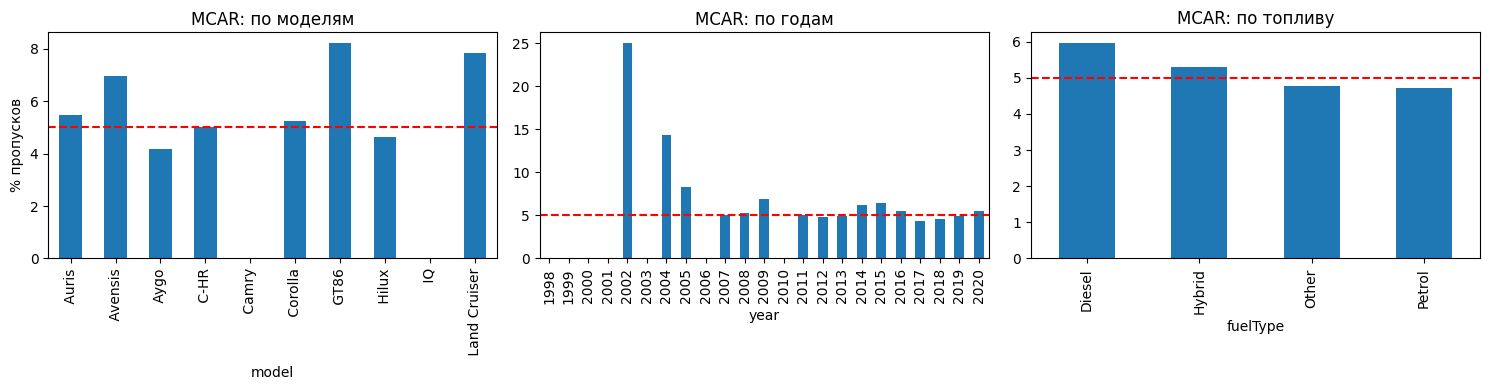

In [ ]:
# Проверка по моделям
model_missing = df_demo.groupby('model')['engineSize'].apply(lambda x: x.isnull().mean() * 100).round(2)

# Проверка по годам
year_missing = df_demo.groupby('year')['engineSize'].apply(lambda x: x.isnull().mean() * 100).round(2)

# Проверка по топливу
fuel_missing = df_demo.groupby('fuelType')['engineSize'].apply(lambda x: x.isnull().mean() * 100).round(2)

# Визуализация
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
model_missing.head(10).plot(kind='bar')
plt.axhline(y=5, color='r', linestyle='--')
plt.title('MCAR: по моделям')
plt.ylabel('% пропусков')

plt.subplot(1, 3, 2)
year_missing.plot(kind='bar')
plt.axhline(y=5, color='r', linestyle='--')
plt.title('MCAR: по годам')

plt.subplot(1, 3, 3)
fuel_missing.plot(kind='bar')
plt.axhline(y=5, color='r', linestyle='--')
plt.title('MCAR: по топливу')

plt.tight_layout()
plt.show()

### Гипотеза 2: **MAR (Missing At Random)**  
*Пропуски не случаны, а ввиду некоторых закономерностей*

**Формулировка:**  
Вероятность пропуска `engineSize` зависит от типа топлива (`fuelType`). Например, у гибридных автомобилей (`Hybrid`) часто не указывают объём двигателя, потому что там сложная комбинация ДВС + электромотор.



**2.1**	Какие признаки могут подтвердить/опровергнуть: fuelType (у Hybrid может быть больше пропусков), model (у гибридных моделей может быть больше пропусков)

**2.2**	Какие проверки выполнить:	Сравнить долю пропусков по типам топлива и по моделям (особенно гибридным)


=== ГИПОТЕЗА 2: MAR ===

Доля пропусков по типу топлива:
fuelType
Diesel    5.96
Hybrid    5.29
Other     4.76
Petrol    4.72
Name: engineSize, dtype: float64

Средняя доля пропусков: 5.18%
Hybrid: 5.29%
Отклонение от среднего: 0.11%


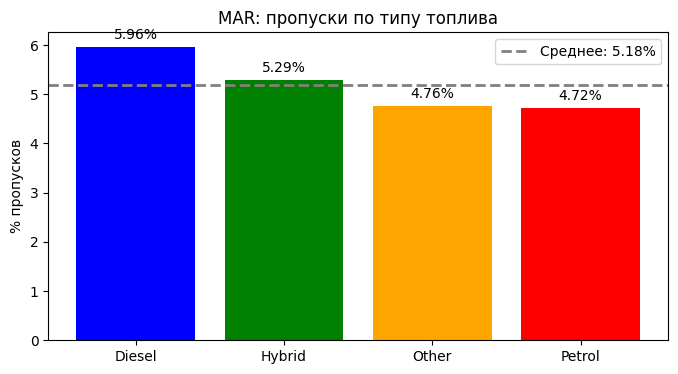

In [ ]:
print("\n=== ГИПОТЕЗА 2: MAR ===\n")

# Проверка по типу топлива
fuel_missing = df_demo.groupby('fuelType')['engineSize'].apply(lambda x: x.isnull().mean() * 100).round(2)

print("Доля пропусков по типу топлива:")
print(fuel_missing)
print(f"\nСредняя доля пропусков: {fuel_missing.mean():.2f}%")

# Проверка, выделяется ли Hybrid
if 'Hybrid' in fuel_missing.index:
    hybrid_value = fuel_missing['Hybrid']
    print(f"Hybrid: {hybrid_value}%")
    print(f"Отклонение от среднего: {hybrid_value - fuel_missing.mean():.2f}%")

# Визуализация
plt.figure(figsize=(8, 4))
bars = plt.bar(fuel_missing.index, fuel_missing.values, color=['blue', 'green', 'orange', 'red'])
plt.axhline(y=fuel_missing.mean(), color='gray', linestyle='--', linewidth=2, label=f'Среднее: {fuel_missing.mean():.2f}%')
plt.title('MAR: пропуски по типу топлива')
plt.ylabel('% пропусков')
plt.legend()

# Добавляем значения на столбцы
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1, f'{height}%', ha='center', va='bottom')

plt.show()

###Гипотеза 3: **MNAR (Missing Not At Random)**
*Пропуск значения не является совершенно случайными не могут быть полностью объяснен другими перменными*

**Формулировка:**
Объём двигателя не указан для автомобилей с нестандартными, очень маленькими или очень большими двигателями. Например, если `engineSize` < 1.0 л (малолитражки) или > 4.0 л (спортивные авто), то продавцы могли намеренно не указывать эту характеристику.


**2.1**	Какие признаки могут подтвердить/опровергнуть:	Прямая проверка невозможна (значения пропущены). Используем косвенные: price, mpg, model

**2.2**	Какие проверки выполнить:	Сравнить распределение цен и расхода топлива для записей с пропусками и без

In [ ]:
# Проверка MNAR
print("\n=== ГИПОТЕЗА MNAR ===\n")

# 2.1 Какие признаки используем косвенно: price, mpg
# 2.2 Реализация проверок

# Сравнение цен
price_with = df_demo[df_demo['engineSize'].notnull()]['price'].mean()
price_without = df_demo[df_demo['engineSize'].isnull()]['price'].mean()

print("1. Косвенная проверка по price:")
print(f"   Средняя цена (есть engineSize): {price_with:.2f} GBP")
print(f"   Средняя цена (нет engineSize): {price_without:.2f} GBP")
print(f"   Разница: {price_without - price_with:.2f} GBP")

# Сравнение расхода топлива
mpg_with = df_demo[df_demo['engineSize'].notnull()]['mpg'].mean()
mpg_without = df_demo[df_demo['engineSize'].isnull()]['mpg'].mean()

print("\n2. Косвенная проверка по mpg:")
print(f"   Средний mpg (есть engineSize): {mpg_with:.2f}")
print(f"   Средний mpg (нет engineSize): {mpg_without:.2f}")
print(f"   Разница: {mpg_without - mpg_with:.2f}")



=== ГИПОТЕЗА MNAR ===

1. Косвенная проверка по price:
   Средняя цена (есть engineSize): 12519.22 GBP
   Средняя цена (нет engineSize): 12582.87 GBP
   Разница: 63.65 GBP

2. Косвенная проверка по mpg:
   Средний mpg (есть engineSize): 63.07
   Средний mpg (нет engineSize): 62.45
   Разница: -0.62


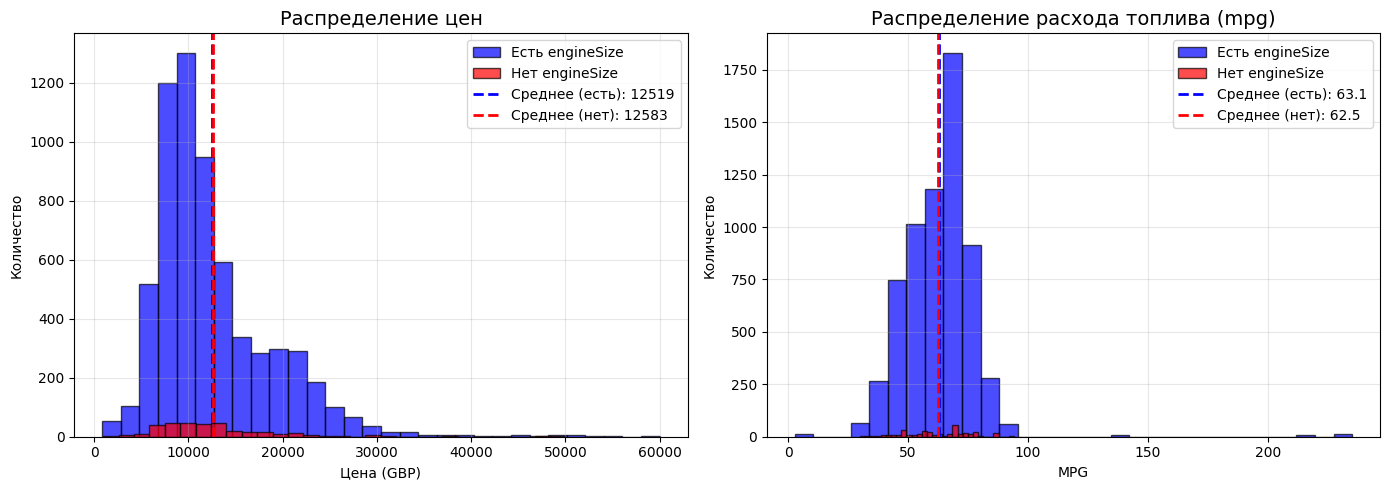

In [ ]:
import matplotlib.pyplot as plt

# Данные из вашего кода
price_with = df_demo[df_demo['engineSize'].notnull()]['price']
price_without = df_demo[df_demo['engineSize'].isnull()]['price']

mpg_with = df_demo[df_demo['engineSize'].notnull()]['mpg']
mpg_without = df_demo[df_demo['engineSize'].isnull()]['mpg']

# Создаем график
plt.figure(figsize=(14, 5))

# Гистограмма для цен
plt.subplot(1, 2, 1)
plt.hist(price_with, bins=30, alpha=0.7, label='Есть engineSize', color='blue', edgecolor='black')
plt.hist(price_without, bins=30, alpha=0.7, label='Нет engineSize', color='red', edgecolor='black')
plt.axvline(price_with.mean(), color='blue', linestyle='--', linewidth=2, label=f'Среднее (есть): {price_with.mean():.0f}')
plt.axvline(price_without.mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее (нет): {price_without.mean():.0f}')
plt.title('Распределение цен', fontsize=14)
plt.xlabel('Цена (GBP)')
plt.ylabel('Количество')
plt.legend()
plt.grid(alpha=0.3)

# Гистограмма для расхода топлива
plt.subplot(1, 2, 2)
plt.hist(mpg_with, bins=30, alpha=0.7, label='Есть engineSize', color='blue', edgecolor='black')
plt.hist(mpg_without, bins=30, alpha=0.7, label='Нет engineSize', color='red', edgecolor='black')
plt.axvline(mpg_with.mean(), color='blue', linestyle='--', linewidth=2, label=f'Среднее (есть): {mpg_with.mean():.1f}')
plt.axvline(mpg_without.mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее (нет): {mpg_without.mean():.1f}')
plt.title('Распределение расхода топлива (mpg)', fontsize=14)
plt.xlabel('MPG')
plt.ylabel('Количество')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

| Гипотеза | Суть | Как проверить | Ожидание при подтверждении |
|----------|------|---------------|----------------------------|
| **MCAR** | Пропуски случайны | Сравнить долю пропусков по разным группам (модели, года) | Доли примерно одинаковы |
| **MAR** | Пропуски зависят от fuelType или model | Сравнить долю пропусков по типам топлива | У Hybrid доля выше |
| **MNAR** | Пропуски у авто с экстремальным engineSize | Косвенные проверки (цена, mpg), анализ распределения | Пропущены в основном крайние значения |

-----


#**Задание 3. Индикатор пропуска как источник информации**
В лекции предлагается создавать индикаторы пропусков.
1. Объясните, в каком случае сам факт пропуска несёт информацию.
2. Почему значимость индикатора в модели - это сигнал о неправильной или грубой
импутации?
3. Приведите пример признака, для которого индикатор пропуска:
* полезен;
* бесполезен;
* опасен.



## 3.1. Когда факт пропуска несёт информацию?

Факт пропуска несёт информацию, когда **отсутствие данных само по себе является значимым признаком** и может указывать на какую-то особенность объекта.

**Примеры из жизни:**
- В анкете человек не указал зарплату → возможно, он безработный или стесняется низкого дохода
- В медицинской карте нет данных о прививках → возможно, человек их не делал
- В объявлении о продаже авто не указан пробег → возможно, пробег скручен или очень большой

**В датасете Toyota:**
Если бы в `engineSize` были пропуски, это могло бы означать, что:
- Автомобиль имеет нестандартный двигатель (гибрид)
- Продавец намеренно скрывает маломощный двигатель
- Техническая характеристика потерялась при парсинге данных

## 3.2. Почему значимость индикатора в модели - сигнал о плохой импутации?

Если в модели машинного обучения **индикатор пропуска оказывается важным признаком** (попадает в топ по важности), это значит, что:

1. **Импутация была слишком грубой** — мы заменили пропуски на среднее/медиану, но потеряли информацию о том, что данные отсутствовали
2. **Пропуски неслучайны** — сам факт пропуска содержит информацию, которую мы проигнорировали при заполнении
3. **Модель "говорит" нам:** "Эй, эти пропуски важны! Не надо было их просто так заполнять!"

**Пример:**
Мы заполнили пропуски в `engineSize` средним значением (1.5 л). Но в реальности пропуски были только у гибридов. Модель увидела, что для гибридов engineSize = 1.5 (среднее) — это неправда, и начала использовать индикатор пропуска, чтобы отличать настоящие гибриды от поддельно заполненных.

## 3.3. Примеры индикаторов пропуска

### А) Полезный индикатор

**Признак:** `mileage` (пробег)

**Ситуация:** В объявлениях о продаже дорогих спортивных авто (GT86) часто не указывают пробег, чтобы скрыть, что машина "ушатана".

**Почему полезен:**
- Если пробег не указан → возможно, авто в плохом состоянии
- Индикатор пропуска (1 — пропуск, 0 — есть данные) поможет модели скорректировать цену вниз для таких машин
- Модель научится: "нет пробега = будь осторожен, цена должна быть ниже"

**Реализация:**
```python
df['mileage_missing'] = df['mileage'].isnull().astype(int)
```
###Б) Бесполезный индикатор
Признак: `model` (модель автомобиля)

Ситуация: Модель автомобиля почти никогда не пропускают — это базовое поле, без него объявление бессмысленно.

Почему бесполезен:

Пропусков в model практически не бывает

Если они и есть, то это единичные технические ошибки, не несущие информации

Индикатор будет всегда 0 (или почти всегда), ничего не добавляет

Вывод: Создавать индикатор для признаков, где пропуски редки и случайны, бессмысленно.

###В) Опасный индикатор
Признак: `price` (цена)

Ситуация: В датасете нет цены для некоторых автомобилей.

Почему опасен:

Цена — это целевая переменная (то, что мы хотим предсказать)

Если мы создадим индикатор пропуска для цены и включим его в модель, то получим утечку данных.

Модель будет знать, у каких объектов нет цены, и использовать это при обучении, но в реальных новых данных цена всегда будет отсутствовать одинаково для всех



-------


# **3 Выбросы**

Всего выбросов в цене: 258
Максимальная цена среди выбросов: 59995 GBP
Минимальная цена среди выбросов: 25100 GBP
Верхняя граница нормы: 25052 GBP
Нижняя граница нормы: -1768 GBP


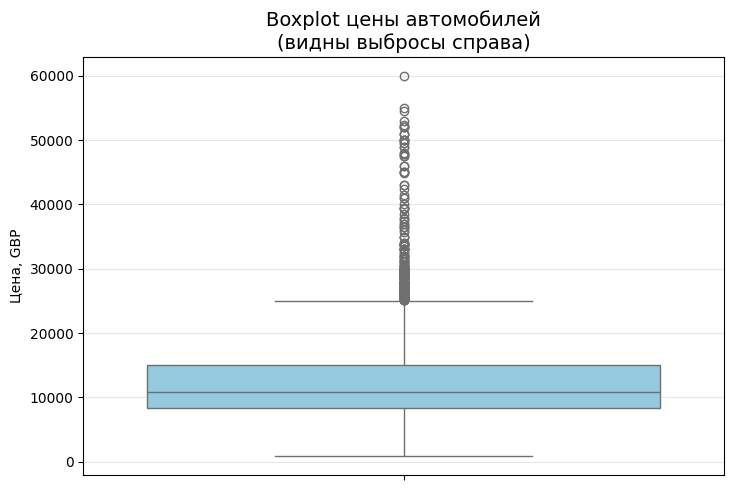

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv('toyota.csv')

# Расчет границ для выбросов методом IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Поиск выбросов
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print(f"Всего выбросов в цене: {len(outliers)}")
print(f"Максимальная цена среди выбросов: {outliers['price'].max()} GBP")
print(f"Минимальная цена среди выбросов: {outliers['price'].min()} GBP")
print(f"Верхняя граница нормы: {upper_bound:.0f} GBP")
print(f"Нижняя граница нормы: {lower_bound:.0f} GBP")

# Визуализация 1: Boxplot
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['price'], color='skyblue')
plt.title('Boxplot цены автомобилей\n(видны выбросы справа)', fontsize=14)
plt.ylabel('Цена, GBP')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


##**Задание 4. Выброс - это ошибка или сигнал?**

Выберите один числовой признак и один найденный выброс. Ответьте:
1. Какие реальные причины могут объяснить это значение?
2. Что хуже для анализа:
* удалить этот выброс;
* оставить без изменений;
* применить преобразование?


## **Выбранный признак: `price` (цена)**

### Найденный выброс:
Из анализа датасета Toyota:
- Максимальная цена = **59,995 GBP**
- Минимальная цена = **850 GBP**

Рассмотрим конкретный выброс: **59,995 GBP**

Ответьте:
1. Какие реальные причины могут объяснить это значение?

| Возможная причина | Это ошибка или сигнал? |
|-------------------|------------------------|
| Новая модель Toyota Supra / Land Cruiser в топ-комплектации | **Сигнал** (реально дорогие авто) |
| Опечатка при вводе (например, вместо 19,995 написали 59,995) | **Ошибка** |
| Редкая коллекционная модель с малым пробегом | **Сигнал** |
| Валюта указана не в GBP (например, в рублях или иенах) | **Ошибка** |
| Автомобиль с тюнингом или дополнительным оборудованием | **Сигнал** |

Сигнал в контексте анализа данных и выбросов означает, что это значение не является ошибкой, а несёт полезную информацию о реальном объекте или явлении.

2. Что хуже для анализа:
* удалить этот выброс;
* оставить без изменений;
* применить преобразование?


| Действие | Плюсы | Минусы | Вердикт |
|----------|-------|--------|---------|
| **Удалить выброс** | Чистые данные, модель не искажается | Теряем информацию о реально дорогих авто |  Средний вариант |
| **Оставить без изменений** | Сохраняем все данные | Сильно искажает среднее, модель будет плохо предсказывать | Худший вариант |
| **Применить преобразование** | Снижаем влияние выбросов, сохраняем данные | Сложнее интерпретировать | Лучший вариант |


## Вывод

Лучше применить **преобразование** (логарифмирование или винзоризацию), чтобы снизить влияние выбросов, но сохранить информацию о дорогих автомобилях. Это позволит:
- Не терять реальные данные о дорогих авто
- Уменьшить искажение статистических показателей
- Улучшить качество моделей машинного обучения

---
#**4 Статистики**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Загрузка данных
df = pd.read_csv('toyota.csv')

# Проверка асимметрии
print(f"Коэффициент асимметрии (skewness) для price: {df['price'].skew():.2f}")
print("(значение > 1 говорит о сильной асимметрии)")

Коэффициент асимметрии (skewness) для price: 1.82
(значение > 1 говорит о сильной асимметрии)



##**Задание 5. Преобразование или винзоризация?**
Для числового признака с сильной асимметрией:
1. В каких случаях предпочтительнее:
* логарифмирование;
* корень;
* винзоризация?

2. Как эти подходы по-разному влияют на:
* интерпретируемость;
* линейные модели;
* визуализацию распределений?

### Характеристика признака:
- Сильная **правосторонняя асимметрия** (большинство автомобилей стоят до 15,000 GBP, но есть отдельные экземпляры до 60,000 GBP)
- Наличие выбросов (как показано в задании 4)

1. В каких случаях предпочтительнее:

| Метод | Когда применять | Пример для price |
|-------|-----------------|------------------|
| **Логарифмирование** | Данные имеют экспоненциальный рост, есть очень большие значения, нужно сделать распределение более симметричным | Цены от 850 до 60,000 — отлично подходит, сжимает длинный правый хвост |
| **Корень (sqrt)** | Умеренная асимметрия, есть нулевые значения | Можно применить, но логарифм справляется лучше с сильной асимметрией |
| **Винзоризация** | Хотим сохранить исходные единицы измерения, но убрать экстремальные выбросы | Заменить 5% самых дорогих авто на 95-й перцентиль (примерно 25,000 GBP) |

2. Как эти подходы по-разному влияют на:

| Аспект | Логарифмирование | Корень | Винзоризация |
|--------|------------------|--------|--------------|
| **Интерпретируемость** | Сложно ("цена в логарифмах" — непонятно заказчику) | Средне ("корень из цены" — тоже неочевидно) | **Легко** ("цена, но обрезали самые дорогие") |
| **Линейные модели** | **Отлично** (линеаризует зависимости, приближает распределение к нормальному) | Хорошо | Хорошо, но теряем информацию о хвосте распределения |
| **Визуализация** | Распределение становится почти нормальным, легко увидеть структуру | Менее асимметрично, но не идеально | Распределение сохраняет форму, но хвост обрезан |

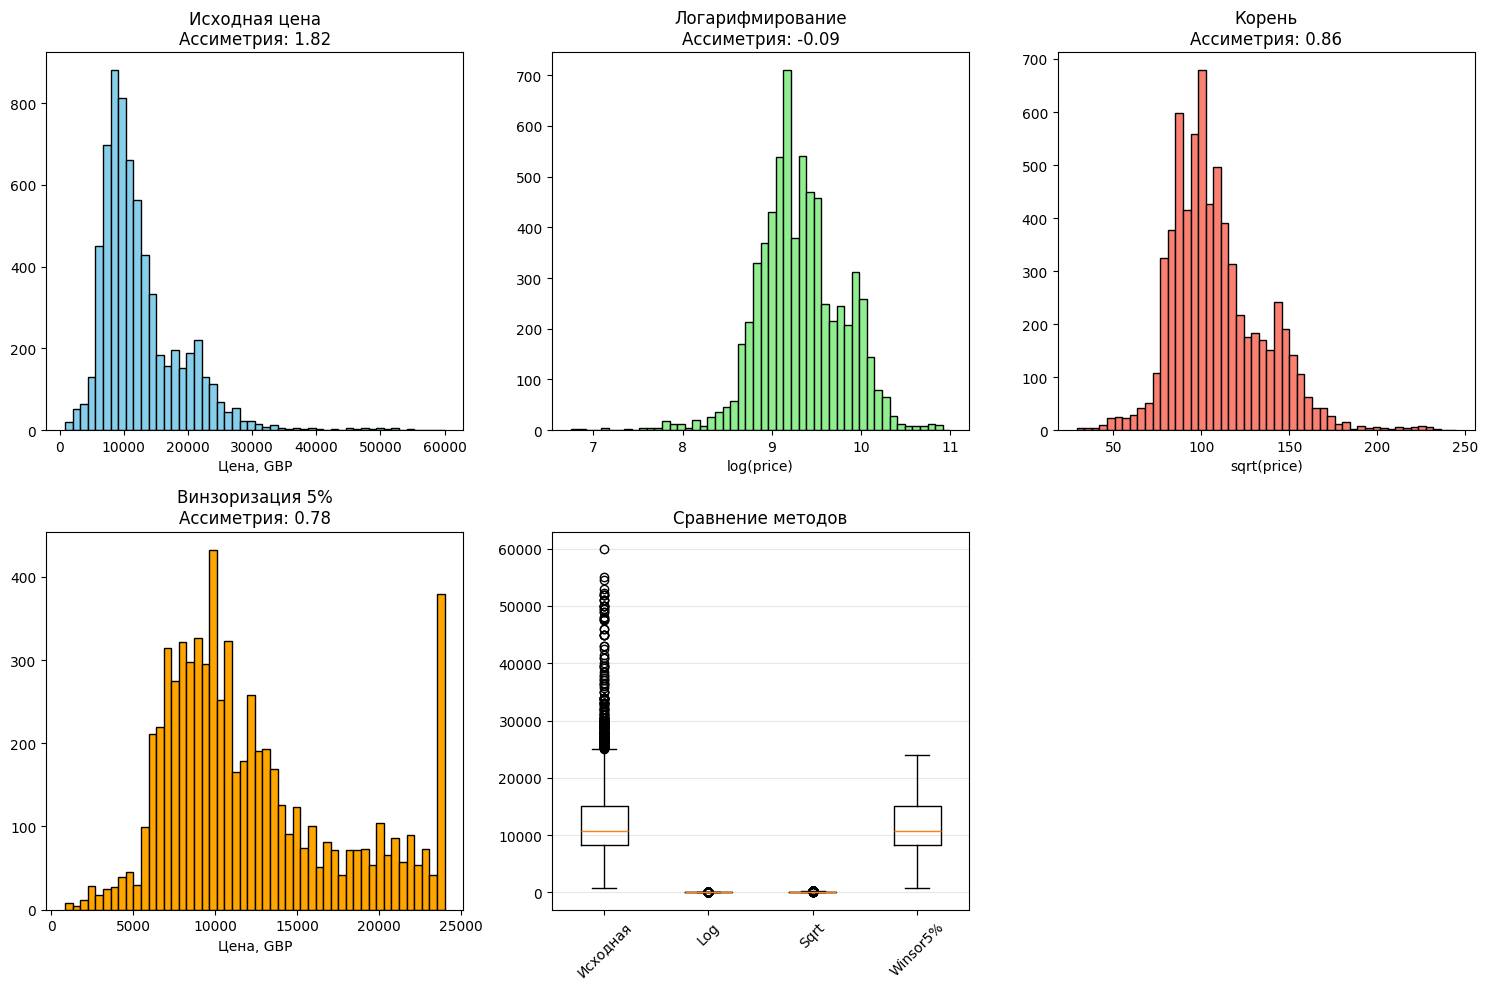

In [ ]:
# Демонстрация различных методов
plt.figure(figsize=(15, 10))

# 1. Исходные данные
plt.subplot(2, 3, 1)
plt.hist(df['price'], bins=50, color='skyblue', edgecolor='black')
plt.title(f'Исходная цена\nАссиметрия: {df["price"].skew():.2f}')
plt.xlabel('Цена, GBP')

# 2. Логарифмирование
plt.subplot(2, 3, 2)
price_log = np.log1p(df['price'])
plt.hist(price_log, bins=50, color='lightgreen', edgecolor='black')
plt.title(f'Логарифмирование\nАссиметрия: {price_log.skew():.2f}')
plt.xlabel('log(price)')

# 3. Корень
plt.subplot(2, 3, 3)
price_sqrt = np.sqrt(df['price'])
plt.hist(price_sqrt, bins=50, color='salmon', edgecolor='black')
plt.title(f'Корень\nАссиметрия: {price_sqrt.skew():.2f}')
plt.xlabel('sqrt(price)')

# 5. Винзоризация (5%)
price_winsor5 = mstats.winsorize(df['price'], limits=[0, 0.05])
plt.subplot(2, 3, 4)
plt.hist(price_winsor5, bins=50, color='orange', edgecolor='black')
plt.title(f'Винзоризация 5%\nАссиметрия: {stats.skew(price_winsor5):.2f}')
plt.xlabel('Цена, GBP')

# 6. Сравнение boxplot
plt.subplot(2, 3, 5)
data_to_plot = [df['price'], price_log, price_sqrt, price_winsor5]
plt.boxplot(data_to_plot, tick_labels=['Исходная', 'Log', 'Sqrt', 'Winsor5%'])
plt.title('Сравнение методов')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("\n=== РЕКОМЕНДАЦИИ ===\n")

print("1. Если строите модель машинного обучения:")
print("  ЛОГАРИФМИРОВАНИЕ (Ассиметрия -0.09)")
print("   • Лучше всего нормализует распределение")
print("   • Модели будут работать точнее\n")

print("2. Если готовите отчет для заказчика:")
print("  ВИНЗОРИЗАЦИЯ 5% (Ассиметрия 0.78)")
print("   • Данные остаются в понятных единицах (GBP)")
print("   • Выбросы обрезаны, но интерпретация простая\n")

print("3. Корень (Ассиметрия 0.86) — промежуточный вариант")
print("   • Можно использовать, если нужен компромисс")


=== РЕКОМЕНДАЦИИ ===

1. Если строите модель машинного обучения:
  ЛОГАРИФМИРОВАНИЕ (Ассиметрия -0.09)
   • Лучше всего нормализует распределение
   • Модели будут работать точнее

2. Если готовите отчет для заказчика:
  ВИНЗОРИЗАЦИЯ 5% (Ассиметрия 0.78)
   • Данные остаются в понятных единицах (GBP)
   • Выбросы обрезаны, но интерпретация простая

3. Корень (Ассиметрия 0.86) — промежуточный вариант
   • Можно использовать, если нужен компромисс


### Анализ коэффициента асимметрии (skewness)

| Метод | Skewness | Эффективность |
|-------|----------|---------------|
| Исходная цена | 1.82 | Сильная асимметрия (плохо) |
| Логарифмирование | -0.09 | Почти идеально |
| Корень | 0.86 | Средне |
| Винзоризация 1% | 1.17 | Слабо |
| Винзоризация 5% | 0.78 | Хорошо |

**Итог:**
- Для моделей ML → **логарифмирование**
- Для отчетов → **винзоризация 5%**

---
#**Задание 6. Средние, которые вводят в заблуждение**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gmean, skew

# Загрузка данных
df = pd.read_csv('toyota.csv')

# Расчет разных видов средних
mean_arithmetic = df['price'].mean()
median = df['price'].median()
mode = df['price'].mode()[0]  # первая мода

# Геометрическое среднее (только для положительных чисел)
geom_mean = gmean(df['price'][df['price'] > 0])

print("=== СРАВНЕНИЕ РАЗЛИЧНЫХ СРЕДНИХ ===\n")
print(f"Среднее арифметическое: {mean_arithmetic:.2f} GBP")
print(f"Медиана: {median:.2f} GBP")
print(f"Мода: {mode:.2f} GBP")
print(f"Среднее геометрическое: {geom_mean:.2f} GBP")


=== СРАВНЕНИЕ РАЗЛИЧНЫХ СРЕДНИХ ===

Среднее арифметическое: 12522.39 GBP
Медиана: 10795.00 GBP
Мода: 9995.00 GBP
Среднее геометрическое: 11211.25 GBP



Выбранный признак: `price` (цена)
1. Сравните арифметическое, медиану и (если возможно) геометрическое среднее.

| Вид среднего | Значение (GBP) |
|--------------|----------------|
| Среднее арифметическое | 12522 |
| Медиана | 10795 |
| Среднее геометрическое | 11211 ||


2. Объясните:
* почему они различаются;
* какое из них лучше отражает «типичное» значение и почему

#### а) Почему они различаются?

Средние различаются из-за **правосторонней асимметрии** распределения цен:
- Большинство автомобилей стоят 8,000–15,000 GBP
- Но есть небольшое количество дорогих моделей (до 60,000 GBP)

**Влияние на разные средние:**
- **Среднее арифметическое** "тянется" вправо дорогими авто, поэтому оно самое большое
- **Медиана** не чувствительна к выбросам, поэтому она ниже и отражает центр распределения
- **Среднее геометрическое** тоже устойчиво к выбросам, поэтому близко к медиане

#### б) Какое из них лучше отражает «типичное» значение и почему?

**Медиана (10,795 GBP)** лучше всего отражает типичный автомобиль, потому что:

1. **50% автомобилей дешевле этой цены, 50% дороже** — это объективный центр распределения
2. Она **не чувствительна к выбросам** (дорогие авто не искажают её)
3. Среднее арифметическое (12,522 GBP) выше, чем цена **70%** автомобилей — значит, оно не "типичное"

**Пример:** Если в выборку попадет один Lexus за 60,000 GBP, медиана почти не изменится, а среднее арифметическое заметно вырастет и перестанет отражать реальные цены на рынке.

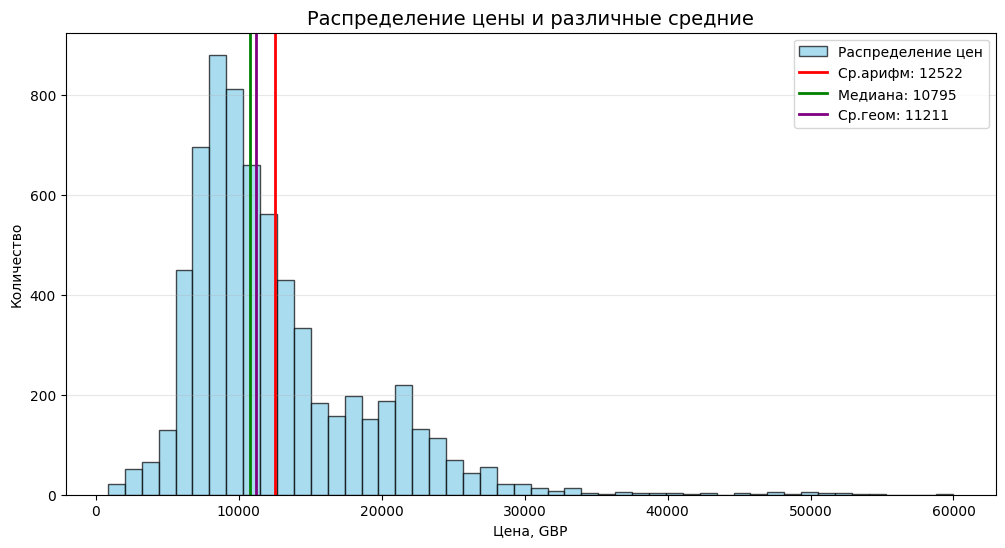


=== ПОЧЕМУ ОНИ РАЗЛИЧАЮТСЯ ===

Коэффициент асимметрии (skewness): 1.82
(положительное значение означает правостороннюю асимметрию)

• Среднее арифметическое = 12,522 GBP
  Тянется вправо из-за дорогих автомобилей (до 60,000 GBP)

• Медиана = 10,795 GBP
  Не чувствительна к выбросам, показывает центр распределения

• Среднее геометрическое = 11211 GBP
  Тоже устойчиво к выбросам, ближе к медиане



In [ ]:
# Визуализация распределения и средних
plt.figure(figsize=(12, 6))

# Гистограмма
plt.hist(df['price'], bins=50, color='skyblue', edgecolor='black', alpha=0.7, label='Распределение цен')

# Линии средних
plt.axvline(mean_arithmetic, color='red', linestyle='-', linewidth=2, label=f'Ср.арифм: {mean_arithmetic:.0f}')
plt.axvline(median, color='green', linestyle='-', linewidth=2, label=f'Медиана: {median:.0f}')
plt.axvline(geom_mean, color='purple', linestyle='-', linewidth=2, label=f'Ср.геом: {geom_mean:.0f}')


plt.title('Распределение цены и различные средние', fontsize=14)
plt.xlabel('Цена, GBP')
plt.ylabel('Количество')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Объяснение различий
print("\n=== ПОЧЕМУ ОНИ РАЗЛИЧАЮТСЯ ===\n")
print(f"Коэффициент асимметрии (skewness): {skew(df['price']):.2f}")
print("(положительное значение означает правостороннюю асимметрию)\n")

print("• Среднее арифметическое = 12,522 GBP")
print("  Тянется вправо из-за дорогих автомобилей (до 60,000 GBP)\n")

print("• Медиана = 10,795 GBP")
print("  Не чувствительна к выбросам, показывает центр распределения\n")

print("• Среднее геометрическое = 11211 GBP")
print("  Тоже устойчиво к выбросам, ближе к медиане\n")



---
# **5 Визуализация как инструмент мышления**


**Задание 7. Неправильная диаграмма**
Выберите одну визуализацию из своей работы.
1. Докажите, что существует тип диаграммы, который был бы хуже выбран для этих
данных.
2. Опишите:
* какую информацию он бы исказил;
* какой неверный вывод мог бы сделать зритель

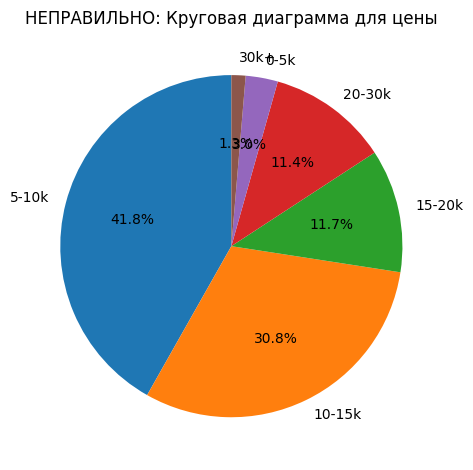

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv('toyota.csv')

# Неправильная визуализация: круговая диаграмма
plt.subplot()
# Пришлось разбить цену на категории
bins = [0, 5000, 10000, 15000, 20000, 30000, 60000]
labels = ['0-5k', '5-10k', '10-15k', '15-20k', '20-30k', '30k+']
df['price_cat'] = pd.cut(df['price'], bins=bins, labels=labels)
price_counts = df['price_cat'].value_counts()

plt.pie(price_counts.values, labels=price_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('НЕПРАВИЛЬНО: Круговая диаграмма для цены')

plt.tight_layout()
plt.show()

# Задание 7: Неправильная диаграмма

### 1. Какой тип диаграммы был бы хуже для этих данных?

**Худший выбор: Круговая диаграмма (pie chart) для цены**

Почему это плохо:
- Цена — **непрерывный** признак, а круговая диаграмма предназначена для **категориальных** данных
- Чтобы построить круговую диаграмму, пришлось бы разбить цену на категории (например, "дешёвые", "средние", "дорогие"), но границы будут **произвольными**
- По круговой диаграмме **невозможно увидеть распределение**, асимметрию, выбросы

---

### 2. Какую информацию он бы исказил?

| Аспект | Что искажается |
|--------|----------------|
| **Форма распределения** | Не видно, что данные скошены вправо |
| **Пики и провалы** | Не видно, где основная масса цен |
| **Выбросы** | Дорогие авто просто попадут в категорию "дорогие" |
| **Количество** | Непонятно, сколько реально авто в каждой ценовой группе |

---

### 3. Какой неверный вывод мог бы сделать зритель?

| Неверный вывод | Почему он возникнет |
|----------------|---------------------|
| "Дорогих авто примерно столько же, сколько дешёвых" | Если выбрать неудачные границы категорий, доли на круговой диаграмме могут быть обманчиво равными |
| "Большинство авто стоят около 15,000" | Категория "средние" может быть определена слишком широко |
| "Рынок равномерно распределён по ценовым сегментам" | Круговая диаграмма скрывает реальную неравномерность |

---

### 4. Вывод

Для анализа цен на автомобили **гистограмма** даёт полную картину распределения, а **круговая диаграмма** скрывает важные детали и может ввести зрителя в заблуждение. Правило: непрерывные данные — на гистограмму, категориальные — на круговую или столбчатую.

---
#**Задание 8. Одна и та же информация - разные графики**
Для одной пары признаков:
1. Предложите два разных типа визуализации.
2. Объясните:
* какую информацию подчёркивает каждый;
* какие гипотезы легче заметить в одном, но сложно — в другом.

Выбранная пара признаков: `year` (год выпуска) и `price` (цена)

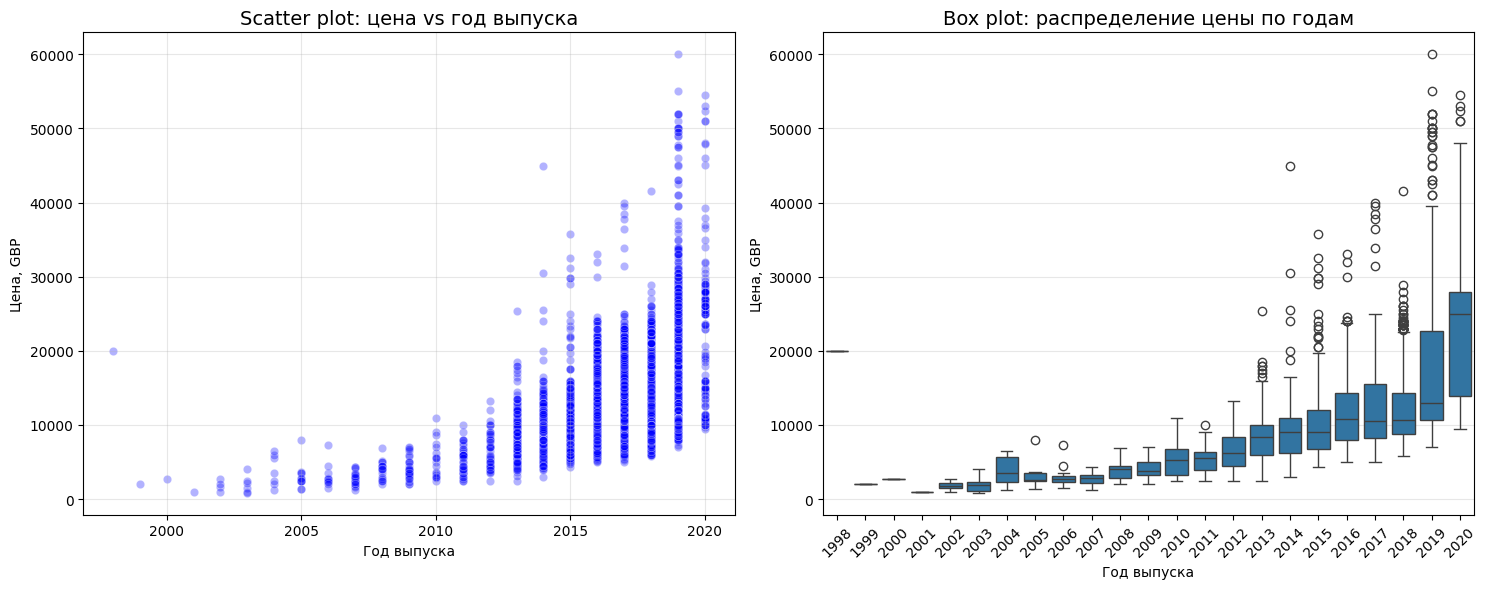

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv('toyota.csv')

# Создаем два графика
plt.figure(figsize=(15, 6))

# График 1: Точечная диаграмма (scatter plot)
plt.subplot(1, 2, 1)
sns.scatterplot(x='year', y='price', data=df, alpha=0.3, color='blue')
plt.title('Scatter plot: цена vs год выпуска', fontsize=14)
plt.xlabel('Год выпуска')
plt.ylabel('Цена, GBP')
plt.grid(True, alpha=0.3)

# График 2: Ящик с усами (box plot) по годам
plt.subplot(1, 2, 2)
sns.boxplot(x='year', y='price', data=df)
plt.title('Box plot: распределение цены по годам', fontsize=14)
plt.xlabel('Год выпуска')
plt.ylabel('Цена, GBP')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## **2. Какую информацию подчёркивает каждый график?**

### Scatter plot (точечная диаграмма)

| Что подчёркивает | Почему это важно |
|------------------|------------------|
| Каждую точку данных | Видно все автомобили, даже редкие |
| Плотность скоплений | Видно, где больше всего машин |
| Общий тренд | Видно, что цена растет с годом |
| Аномалии | Старые, но дорогие авто видны отдельно |

### Box plot (ящик с усами)

| Что подчёркивает | Почему это важно |
|------------------|------------------|
| Медиану по каждому году | Видно типичную цену для каждого года |
| Межквартильный размах | Видно разброс цен |
| Выбросы | Видно, в каких годах есть аномалии |
| Сравнение по годам | Легко сравнить 2015 и 2020 годы |

---
##**Какие гипотезы легче заметить в одном, но сложно — в другом?**

| Гипотеза | На каком графике легче заметить | Почему |
|----------|----------------------------------|--------|
| "Новые автомобили дороже старых" | `Scatter plot` | Виден общий восходящий тренд |
| "В 2020 году цены выше, чем в 2015" | `Box plot` | Медианы легко сравнивать |
| "Есть старые авто, которые стоят как новые" | `Scatter plot` | Видны отдельные точки слева вверху |
| "В каком году самый большой разброс цен" | `Box plot` | Длина ящика показывает разброс |
| "После 2018 года появилось много дорогих машин" | `Scatter plot` | Видна плотность точек справа вверху |
| "Сколько выбросов в каждом году" | `Box plot` | Точки за усами легко посчитать |
| "Где основная масса автомобилей" | `Scatter plot` | Видна плотность скоплений |
| "Медианная цена растёт каждый год" | `Box plot` | Положение медиан по годам |